Index([424, 1885, 3346, 4807, 6268, 7729, 9190, 10651, 12112, 13573, 15034], dtype='int64')
(15706, 1)
(15695, 1)
[0.63016963] [-0.38863347] [-0.80855622]
(15706,)
0.6301696327422706 0.12076808217340529 -0.38863346839546
***check*** BAM index shape:  (15706,)


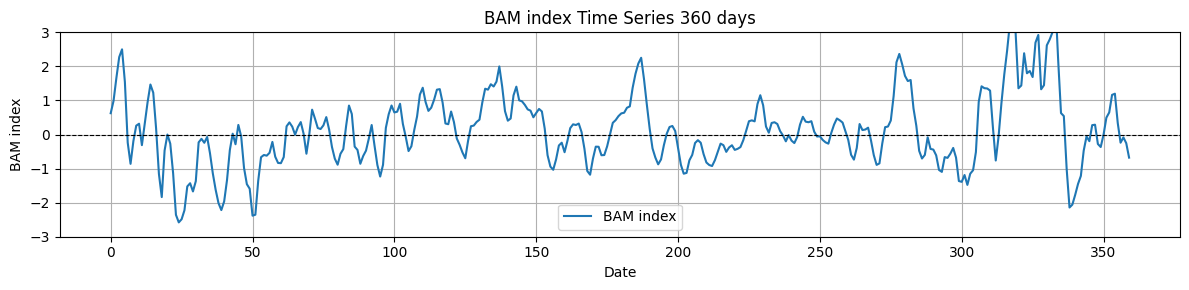

In [ ]:
from scipy.io import netcdf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import datetime as dt
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import pandas as pd
import glob
import copy
import pickle
import matplotlib.path as mpath
from netCDF4 import Dataset
import xarray as xr



In [ ]:
datasets = ["ERA5", "MERRA2", "JRA55"]

OUT_DIR_List = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2",
    "JRA55": "/scratch/bell/hu1029/LGHW/interm_JRA55"
}
yearnameList = {
    "ERA5": "1979_2021",
    "MERRA2": "1980_2021",
    "JRA55": "1979_2021"
}
timerefFile = {
    "ERA5": "/scratch/bell/hu1029/Data/processed/ERA5_Z500_6hr_1979_2021_1dg.nc",
    "MERRA2": "/scratch/bell/hu1029/Data/processed/MERRA2_Z500_6hr_1980_2021_1dg.nc",
    "JRA55": "/scratch/bell/hu1029/Data/processed/JRA55_Z500_6hr_1979_2021_1dg.nc"
}
latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lat_1979_2021_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lat_1980_2021_6hr.npy",
    "JRA55": "/scratch/bell/hu1029/LGHW/interm_JRA55/JRA55_LWA_lat_1979_2021_6hr.npy"
}
lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lon_1979_2021_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lon_1980_2021_6hr.npy",
    "JRA55": "/scratch/bell/hu1029/LGHW/interm_JRA55/JRA55_LWA_lon_1979_2021_6hr.npy"
}
TRACK_latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lat_1979_2021_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lat_1980_2021_6hr.npy",
    "JRA55": "/scratch/bell/hu1029/LGHW/interm_JRA55/JRA55_TRACK_lat_1979_2021_6hr.npy"
}
TRACK_lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lon_1979_2021_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lon_1980_2021_6hr.npy",
    "JRA55": "/scratch/bell/hu1029/LGHW/interm_JRA55/JRA55_TRACK_lon_1979_2021_6hr.npy"
}

In [ ]:
dtname = 'ERA5'
yearname = yearnameList[dtname]
OUTDIR = OUT_DIR_List[dtname]
reflat = latrefFile[dtname]
reflon = lonrefFile[dtname]
timereff = timerefFile[dtname]

In [ ]:
typeid = 1
rgname = "ATL"
ss = "ALL"
cyc = "AC"

#%% 01 read the data ---------------------------------------------------------
# time management
### Time Management ###
start_year, end_year = map(int, yearname.split('_'))
Datestamp = pd.date_range(start=f"{start_year}-01-01", end=f"{end_year}-12-31")
Date0 = pd.DataFrame({'date': pd.to_datetime(Datestamp)})
Date = list(Date0['date'])
nday = len(Date0)
Month = Date0['date'].dt.month
Year = Date0['date'].dt.year
Day = Date0['date'].dt.day
Datelist = list(Date0)
# BAM dates
feb_29_ind = Date0[(Month == 2) & (Day == 29)].index
print(feb_29_ind, flush=True)
# Remove February 29 from the Date DataFrame
print(Date0.shape, flush=True)
# BAMDate = Date0.drop(index=feb_29_ind).reset_index(drop=True) # BAMDate: the Date index for BAM index, without February 29
# print(BAMDate.shape, flush=True)

# read the BAM index
if rgname == "SH":
    BI = np.load(f'{OUTDIR}/{dtname}_SH_BAM_index_total_no_leap.npy')    ## This is full BAM index from 1979 to 2021, no leap years ###
else:
    BI = np.load(f'{OUTDIR}/{dtname}_NH_BAM_index_total_no_leap.npy')    ## This is full BAM index from 1979 to 2021, no leap years ###
print(BI.shape, flush=True)
print(BI[423],BI[424],BI[425],flush=True)  

# get back to the full time
BI_full = np.full(len(Date0), np.nan)
keep_idx = np.setdiff1d(np.arange(len(Date0)), feb_29_ind)
BI_full[keep_idx] = BI.squeeze()
BI_full_series = pd.Series(BI_full)
BI_full_interp = BI_full_series.interpolate(method='linear')
BI_full_interp = BI_full_interp.to_numpy()
print(BI_full_interp.shape)
print(BI_full_interp[423],BI_full_interp[424],BI_full_interp[425],flush=True)  
BI = BI_full_interp
print('***check*** BAM index shape: ', BI.shape, flush=True)

# make a plot to see
plt.figure(figsize=(12, 3))
plt.plot(np.arange(360), BI[0:360], label='BAM index')
plt.ylim(-3, 3)
plt.xlabel('Date')
plt.ylabel('BAM index')
plt.title('BAM index Time Series 360 days')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# plt.savefig('BI_check.png', dpi=300, bbox_inches='tight')
# plt.close()


In [ ]:

# read in the blocking flag, and transfer to 2d array (time, lon)
blockingEidArr = np.load(f'{OUTDIR}/{dtname}_SD_BlockingFlagmaskClusters_Type{typeid}_{rgname}_{ss}.npy') # the blocking event index array
blockingEidArr = np.flip(blockingEidArr, axis=1) # flip the lat
print(blockingEidArr.shape, flush=True)
blockingEidArr_2D = np.any(blockingEidArr, axis=1).astype(int)

lat = np.load("/scratch/bell/hu1029/LGHW/LWA_lat_1979_2021_ERA5_6hr.npy")
lon = np.load("/scratch/bell/hu1029/LGHW/LWA_lon_1979_2021_ERA5_6hr.npy")
lat_mid = int(len(lat)/2) + 1 
if rgname == "SP":
    Blklat = lat[lat_mid:len(lat)]
else:
    Blklat = lat[0:lat_mid-1]
Blklat = np.flip(Blklat) # make it ascending order (from south to north)
print('Blklat: ',Blklat, flush=True)
Blklon = lon 
print('Blklon: ',Blklon, flush=True)
print('***check*** blockingEidArr_2D shape: ', blockingEidArr_2D.shape, flush=True)

# read in LWA data
LWA_td_origin = np.load('/scratch/bell/hu1029/LGHW/LWA_td_1979_2021_ERA5_6hr.npy')  # [0]~[-1] it's from south to north
LWA_td_origin = LWA_td_origin/100000000 # change the unit to 1e8 

T = LWA_td_origin.shape[0]
n = T // 4
arr_reshaped = LWA_td_origin.reshape(n, 4, *LWA_td_origin.shape[1:])
LWA_td_origin_daily = np.nanmean(arr_reshaped, axis=1)  

# read in lat and lon for LWA
# get the lat and lon for LWA, grouped by NH and SH
lat_mid = int(len(lat)/2) + 1 
if rgname == "SP":
    latLWA = lat[lat_mid:len(lat)]
    LWA_td = LWA_td_origin_daily[:,lat_mid:len(lat),:] 
else:
    latLWA = lat[0:lat_mid-1]
    LWA_td = LWA_td_origin_daily[:,0:lat_mid-1,:]
latLWA = np.flip(latLWA) # make it ascending order (from south to north)
LWA_td = np.flip(LWA_td, axis=1) 
print('LWA shape: ', LWA_td.shape, flush=True)
lonLWA = lon 
print('latLWA:', latLWA, flush=True)
print('lonLWA:', lonLWA, flush=True)
ilat = np.where((latLWA >= 20) & (latLWA <= 70))[0]

# transfer the LWA to 2d array (time, lon)
LWA_td_2D = np.nanmean(LWA_td[:, ilat, :], axis=1)
print('***check*** LWA_td_2D shape: ', LWA_td_2D.shape, flush=True)


(15706, 90, 360)
Blklat:  [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36.
 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54.
 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72.
 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89. 90.]
Blklon:  [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 

***check*** LWA_td_anom_2D shape:  (15706, 360)
[[1.04295477 1.03257615 1.02217511 ... 1.07247359 1.06295564 1.05308844]
 [1.04295477 1.03257615 1.02217511 ... 1.07247359 1.06295564 1.05308844]
 [1.04295477 1.03257615 1.02217511 ... 1.07247359 1.06295564 1.05308844]
 ...
 [0.96728669 0.96174597 0.95559549 ... 0.97982558 0.97621624 0.97207583]
 [0.96728669 0.96174597 0.95559549 ... 0.97982558 0.97621624 0.97207583]
 [0.96728669 0.96174597 0.95559549 ... 0.97982558 0.97621624 0.97207583]]
keylon:  0
***check*** keyLWA shape:  (15706,)


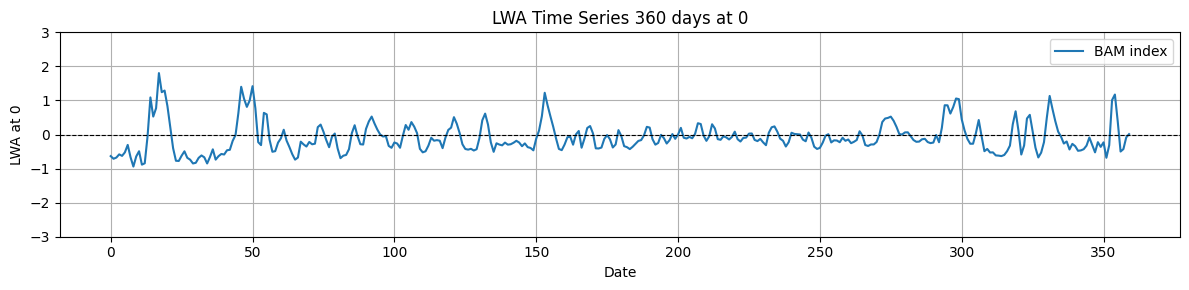

In [ ]:

# get the LWA_2d anomaly as the deviation from the climalogical mean
LWA_td_clim = np.full((12, LWA_td_2D.shape[1]), np.nan)
for m in range(12):
    month_idx = np.where(Month == m+1)[0]
    LWA_td_clim[m,:] = np.nanmean(LWA_td_2D[month_idx,:], axis=0)
LWA_td_anom_2d = np.full(LWA_td_2D.shape, np.nan)
LWA_dailyclim = np.full(LWA_td_2D.shape, np.nan)
for i in range(LWA_td_2D.shape[0]):
    m = Month[i]
    LWA_td_anom_2d[i,:] = LWA_td_2D[i,:] - LWA_td_clim[m-1,:]
    LWA_dailyclim[i,:] = LWA_td_clim[m-1,:]
print('***check*** LWA_td_anom_2D shape: ', LWA_td_anom_2d.shape, flush=True)
print(LWA_dailyclim)

# get the key longitude index
targetlon = 0
keylon = np.where(lonLWA == targetlon)[0][0]
print('keylon: ', keylon, flush=True)
keyLWA = LWA_td_anom_2d[:, keylon]
print('***check*** keyLWA shape: ', keyLWA.shape, flush=True)



0
[0 0 0 ... 0 0 0]
keyLWA_blk_index:  [  104   105   106 ... 15685 15686 15687]
LWAvalues in blocking day:  [0.94958211 0.81001128 1.03585051 ... 0.82515186 1.22028915 1.21705209]
threshold blkLWA (10th):  1.1337514047562416


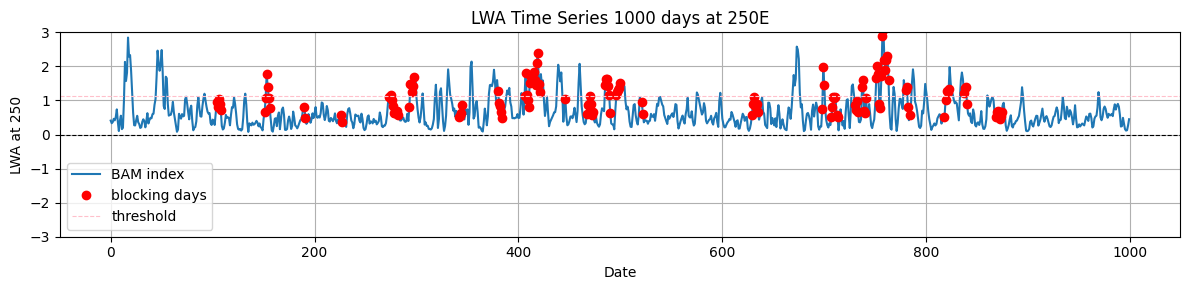

In [4]:
print(keylon)
keyBlkflag = blockingEidArr_2D[:, keylon]
print(keyBlkflag)
# get the Xth LWA value during blocking days
thX = 50
keyLWA_blk_index = np.where(keyBlkflag == 1)[0]
print('keyLWA_blk_index: ', keyLWA_blk_index, flush=True)
keyLWAorigin = LWA_td_2D[:, keylon]
LWAvalues = keyLWAorigin[keyLWA_blk_index]
print('LWAvalues in blocking day: ', LWAvalues, flush=True)
# get the Xth percentile value
blkLWA = np.nanpercentile(LWAvalues, thX)
print('threshold blkLWA (10th): ', blkLWA, flush=True)

# make a plot to see
blkif = np.where(keyBlkflag[0:1000] == 1)[0]
plt.figure(figsize=(12, 3))
plt.plot(np.arange(1000), keyLWAorigin[0:1000], label='BAM index')
plt.plot(np.arange(1000)[blkif], keyLWAorigin[0:1000][blkif], 'ro', label='blocking days')
plt.ylim(-3, 3)
plt.xlabel('Date')
plt.ylabel('LWA at 250')
plt.title('LWA Time Series 1000 days at 250E')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axhline(blkLWA, color='pink', linewidth=0.8, linestyle='--', label='threshold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# plt.savefig('LWAorigin_check.png', dpi=300, bbox_inches='tight')
# plt.close()


9.771885325619613e-17
0.47895980762486196


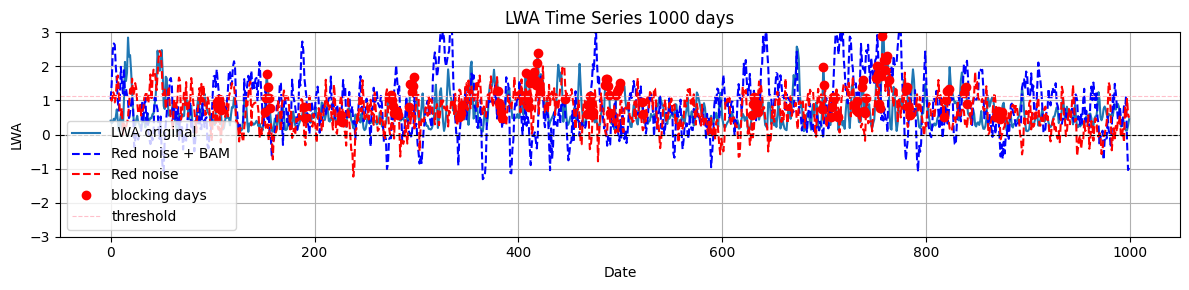

In [5]:

# %%03 build the model using keyLWA and BI ---------------------------
# --- inputs ---
# keyLWA: 1D numpy array (daily LWA anomalies, already anomaly)
# BI    : 1D numpy array (daily BAM index)
# Climatology from the inputs (since anomaly = original - climatology)
clim_full = LWA_dailyclim[:, keylon]
# We will align both simulated anomalies to these target stats
target_mean = float(keyLWA.mean())     # typically ~ 0; small offset (e.g., 0.02) is fine
target_std  = float(keyLWA.std())      # to make magnitudes comparable
print(target_mean)
print(target_std)
N0 = len(keyLWA)                       # length of the time series
N = N0 * 10
clim_repeated = np.tile(clim_full, int(np.ceil(N / len(clim_full))))[:N]

# -----------------------------
# 2) Idealized AR(1) parameters (NOT fitted from data)
# -----------------------------
dt  = 1.0          # 1 day
tau = 2.0          # persistence time (days)
phi = np.exp(-dt / tau)  # ~0.6065 for tau=2
# Choose sigma so that a plain AR(1) would have Var ~ target_std^2
sigma = target_std * np.sqrt(1.0 - phi**2)

# Intercept c0 set to keep the theoretical mean at target_mean (since BAM will be zero-mean)
c0 = (1.0 - phi) * target_mean

# -----------------------------
# 3) Standardize BAM to zero mean and unit std (critical!)
# -----------------------------
BI_std = (BI - BI.mean()) / (BI.std() + 1e-12)
BI_long = np.tile(BI_std, int(np.ceil(N / len(BI_std))))[:N]
# Coupling strength gamma (manual; controls how strongly BAM projects on LWA)
bam_snr = 0.6                 # tune this: 0.3 (weak) ... 1.0 (strong)
bam_snr_c = str(bam_snr).replace('.', 'p')
gamma = bam_snr * target_std  # gives gamma a clear physical scale

# -----------------------------
# 4) Simulate anomalies: (a) pure red noise   (b) red noise + BAM forcing
# -----------------------------
rng = np.random.default_rng(0)

# (a) Red noise (AR(1))
eps_rn = rng.normal(0.0, sigma, size=N)
anom_rn = np.zeros(N)
anom_rn[0] = target_mean
for t in range(1, N):
    anom_rn[t] = phi * anom_rn[t-1] + c0 + eps_rn[t]

# (b) Red noise + BAM (ARX(1) with zero-mean BAM)
eps_bm = rng.normal(0.0, sigma, size=N)
anom_bam = np.zeros(N)
anom_bam[0] = target_mean
for t in range(1, N):
    anom_bam[t] = phi * anom_bam[t-1] + gamma * BI_long[t] + c0 + eps_bm[t]

W_sim_rn  = clim_repeated + anom_rn
W_sim_bam = clim_repeated + anom_bam

# -----------------------------
# 5) Make a plot to see the simulated time series
# -----------------------------
blkif = np.where(keyBlkflag[0:1000] == 1)[0]
plt.figure(figsize=(12, 3))
plt.plot(np.arange(1000), keyLWAorigin[0:1000], label='LWA original')
plt.plot(np.arange(1000), W_sim_bam[0:1000], linestyle='--', color='blue',label='Red noise + BAM')
plt.plot(np.arange(1000), W_sim_rn[0:1000], linestyle='--', color='red', label='Red noise')
plt.plot(np.arange(1000)[blkif], keyLWAorigin[0:1000][blkif], 'ro', label='blocking days')
plt.ylim(-3, 3)
plt.xlabel('Date')
plt.ylabel('LWA')
plt.title('LWA Time Series 1000 days')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axhline(blkLWA, color='pink', linewidth=0.8, linestyle='--', label='threshold')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
# plt.savefig(f'Idealized_DataCheck_{bam_snr_c}.png', dpi=300, bbox_inches='tight')
# plt.close()


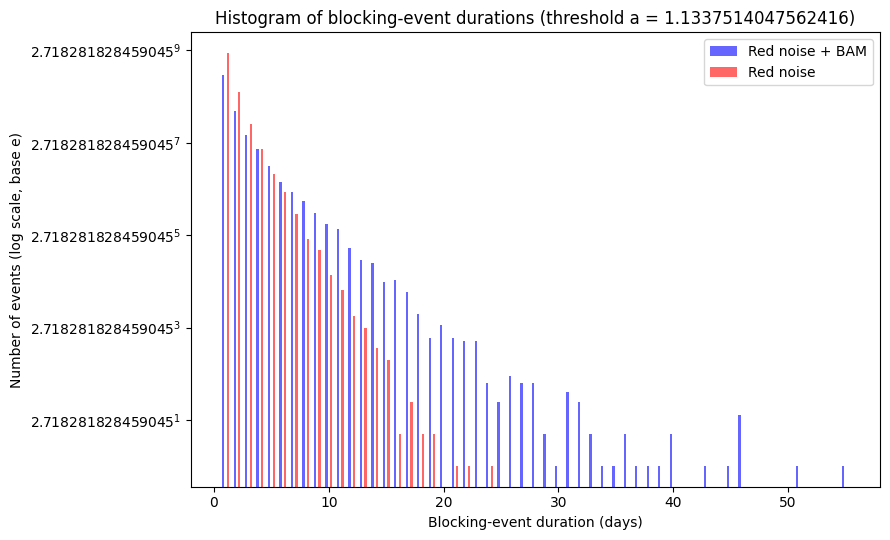

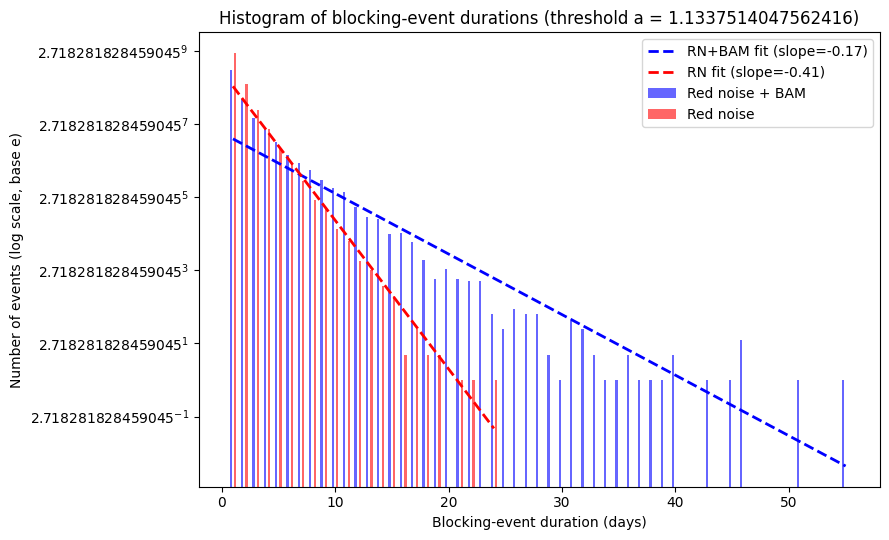

Done!


In [13]:
# %%04 use the blkLWA as the threshold to define the blocking days ---------------------------

x2 = W_sim_bam  # add back the daily climatology
x3 = W_sim_rn  # add back the daily climatology
a = blkLWA

# -----------------------
# Blocking event detection
# -----------------------
def run_lengths_above(series, thr):
    """Return lengths of consecutive runs where series > threshold."""
    above = series > thr
    lens, run = [], 0
    for v in above:
        if v:
            run += 1
        else:
            if run > 0:
                lens.append(run)
                run = 0
    if run > 0:
        lens.append(run)
    return np.array(lens, dtype=int)

lens2 = run_lengths_above(x2, a)
lens3 = run_lengths_above(x3, a)

# Histogram of event durations
K = max(lens2.max() if len(lens2) else 1, lens3.max() if len(lens3) else 1)
bins = np.arange(1, K + 2)  # bins for durations 1,2,3,...
counts2, _ = np.histogram(lens2, bins=bins)
counts3, _ = np.histogram(lens3, bins=bins)
centers = np.arange(1, K + 1)

# -----------------------
# Figure: Histogram of event durations (log y-axis)
# -----------------------
# fig1
plt.figure(figsize=(9, 5.5))
width = 0.2
# Bar plots for the two models
plt.bar(centers - width, counts2, width=width, alpha=0.6, color="blue", label="Red noise + BAM")
plt.bar(centers + width, counts3, width=width, alpha=0.6, color="red", label="Red noise")
# Set log scale (base e)
plt.yscale("log", base=np.e)
plt.xlabel("Blocking-event duration (days)")
plt.ylabel("Number of events (log scale, base e)")
plt.title(f"Histogram of blocking-event durations (threshold a = {a})")
plt.legend()
plt.tight_layout()
# Save before showing
# plt.savefig(f"Idealized_RedNoiseBAM_duration_histogramOnly_bamsnr{bam_snr_c}.png", dpi=300)
plt.show()
# plt.close()


# fig2
plt.figure(figsize=(9, 5.5))
width = 0.2
# --- Bar plots ---
plt.bar(centers - width, counts2, width=width, alpha=0.6, color="blue", label="Red noise + BAM")
plt.bar(centers + width, counts3, width=width, alpha=0.6, color="red",  label="Red noise")
# --- Fit for Red noise + BAM ---
mask2 = counts2 > 0
x2 = centers[mask2]
y2 = counts2[mask2]
m2, b2 = np.polyfit(x2, np.log(y2), 1)   # log(y) = m*x + b
y2_pred = np.exp(m2 * x2 + b2)
plt.plot(x2, y2_pred, "--", color="blue", lw=2, label=f"RN+BAM fit (slope={m2:.2f})")
# --- Fit for Red noise ---
mask3 = counts3 > 0
x3 = centers[mask3]
y3 = counts3[mask3]
m3, b3 = np.polyfit(x3, np.log(y3), 1)
y3_pred = np.exp(m3 * x3 + b3)
plt.plot(x3, y3_pred, "--", color="red", lw=2, label=f"RN fit (slope={m3:.2f})")
# --- Aesthetics ---
plt.yscale("log", base=np.e)
plt.xlabel("Blocking-event duration (days)")
plt.ylabel("Number of events (log scale, base e)")
plt.title(f"Histogram of blocking-event durations (threshold a = {a})")
plt.legend()
plt.tight_layout()
# plt.savefig(f"Idealized_RedNoiseBAM_duration_histogram_bamsnr{bam_snr_c}.png", dpi=300)
plt.show()
# plt.close()
print("Done!")

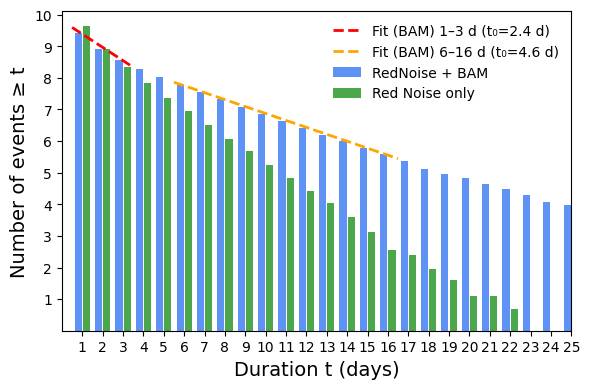

In [14]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))

# ---------- data ----------
lens2 = np.asarray(lens2, dtype=int)
lens3 = np.asarray(lens3, dtype=int)

max_d = min(max(lens2.max(), lens3.max()), 29)   
durations = np.arange(1, max_d + 1)

# exceedance counts
counts2 = np.array([np.sum(lens2 >= t) for t in durations])  # RedNoise+BAM
counts3 = np.array([np.sum(lens3 >= t) for t in durations])  # Red Noise only

# ---------- bars (more spacing between groups) ----------
barw = 0.35  # 
offset = 0.2 # 
plt.bar(durations - offset, counts2, width=barw, alpha=0.7,
        color='#1a66f1', edgecolor='None', label='RedNoise + BAM')
plt.bar(durations + offset, counts3, width=barw, alpha=0.7,
        color='green', edgecolor='None', label='Red Noise only')

plt.xlim(0, 25)  
plt.xticks(np.arange(1, 26, 1))
plt.xlabel('Duration t (days)', fontsize=14)
plt.ylabel('Number of events ≥ t', fontsize=14)

# ---------- log-e y-axis ----------
ax = plt.gca()
ax.set_yscale('log', base=np.e)
ax.set_ylim(bottom=1)

ytop = max(counts2.max(), counts3.max())
kmax = int(np.ceil(np.log(ytop)))
yticks = np.exp(np.arange(1, kmax + 1))
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(1, kmax + 1))  # ln(N)
# plt.grid(axis='y', alpha=0.75, which='both')

# ---------- Linear-fit segments ----------
def fit_and_plot(dmin, dmax, x_all, y_all, color, ls, label_prefix):
    d1 = max(dmin, x_all.min())
    d2 = min(dmax, x_all.max())
    if d2 < d1:
        return
    sel = (x_all >= d1) & (x_all <= d2)
    x = x_all[sel]
    y = y_all[sel]
    m = y > 0
    x = x[m]; y = y[m]
    if x.size < 2:
        return
    b, a = np.polyfit(x, np.log(y), 1)  # ln-space linear fit
    xfit = np.array([d1-0.5, d2+0.5], dtype=float)
    yfit = np.exp(a + b * xfit)
    ax.plot(xfit, yfit, linestyle=ls, lw=2, color=color,
            label=f'{label_prefix} {d1}–{d2} d (t₀={-1.0/b:.1f} d)')

# lens2：blue bar + solid lines
fit_and_plot(1, 3,  durations, counts2, color='red',   ls='--', label_prefix='Fit (BAM)')
fit_and_plot(6, 16, durations, counts2, color='orange', ls='--', label_prefix='Fit (BAM)')

# # lens3：orange bar + dashed lines
# fit_and_plot(1, 3,  durations, counts3, color='red',   ls='--', label_prefix='Fit (Red Noise)') # t0=1.6d
# fit_and_plot(6, 16, durations, counts3, color='green', ls='--', label_prefix='Fit (Red Noise)') # t0 = 2.9d

ax.legend(frameon=False, fontsize=10, loc='best')
plt.tight_layout()
plt.show()